# Predict Health Costs with Regression

This notebook builds a **neural network** that predicts a person's annual healthcare costs from their age, sex, BMI, number of children, smoking status, and region. It's a **regression** task — the model outputs a dollar amount, not a category.


In [11]:
# --- Imports & reproducibility ---
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Set seeds so results are reproducible run-to-run
SEED = 10
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow", tf.__version__)


TensorFlow 2.20.0


## 1. Download & load the data

The **Insurance dataset** comes from freeCodeCamp. It has 1,338 rows with 7 columns:

| Column     | Type     | Description                                        |
| ---------- | -------- | -------------------------------------------------- |
| `age`      | number   | Person's age                                       |
| `sex`      | category | `male` or `female`                                 |
| `bmi`      | number   | Body Mass Index                                    |
| `children` | number   | Number of children on the plan                     |
| `smoker`   | category | `yes` or `no`                                      |
| `region`   | category | One of 4 US regions                                |
| `expenses` | number   | **Annual healthcare cost** (the target to predict) |


In [12]:
# Download the data (skip if already present)
if not os.path.exists("insurance.csv"):
    !wget -q https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv

dataset = pd.read_csv("insurance.csv")
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [13]:
# Inspect data types and unique category values
dataset.info()
print()
print("sex values:    ", dataset["sex"].unique())
print("smoker values: ", dataset["smoker"].unique())
print("region values: ", dataset["region"].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

sex values:     ['female' 'male']
smoker values:  ['yes' 'no']
region values:  ['southwest' 'southeast' 'northwest' 'northeast']


## 2. Convert categories to numbers

Neural networks only understand numbers, so we convert text categories:

- **Binary features** (`sex`, `smoker`): map to 0/1 (only 2 values, so order doesn't matter).
- **Multi-valued feature** (`region`): **one-hot encode** — create a yes/no column for each region. Mapping 4 regions to 0/1/2/3 would imply a false ordering (as if `northeast` is "more" than `southwest`).


In [14]:
# Binary features: ordinal encoding (0 / 1)
sex_map = {"male": 0, "female": 1}
smoker_map = {"no": 0, "yes": 1}

dataset["sex"] = dataset["sex"].map(sex_map)
dataset["smoker"] = dataset["smoker"].map(smoker_map)

# Nominal feature: one-hot encode (4 regions, no natural ordering)
dataset = pd.get_dummies(dataset, columns=["region"], dtype=float)

In [15]:
dataset.tail()

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
1333,50,0,31.0,3,0,10600.55,0.0,1.0,0.0,0.0
1334,18,1,31.9,0,0,2205.98,1.0,0.0,0.0,0.0
1335,18,1,36.9,0,0,1629.83,0.0,0.0,1.0,0.0
1336,21,1,25.8,0,0,2007.95,0.0,0.0,0.0,1.0
1337,61,1,29.1,0,1,29141.36,0.0,1.0,0.0,0.0


## 3. Split into train and test sets

We use 80% of the data for **training** and 20% for **testing**. The `expenses` column is our **target** (what we predict); the rest are **features** (what we predict from).

We convert to NumPy `float32` arrays so Keras 3 can process them without dtype issues.


In [16]:
train_dataset = dataset.sample(frac=0.8, random_state=SEED)
test_dataset = dataset.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("expenses")
test_labels = test_features.pop("expenses")

# Convert to float32 numpy arrays (Keras 3 compatibility)
train_features = np.array(train_features, dtype="float32")
test_features = np.array(test_features, dtype="float32")
train_labels = np.array(train_labels, dtype="float32")
test_labels = np.array(test_labels, dtype="float32")

print("Training samples:", train_features.shape[0])
print("Test samples:    ", test_features.shape[0])
print("Features:        ", train_features.shape[1])

Training samples: 1070
Test samples:     268
Features:         9


## 4. Build the neural network

| Layer                | What it does                                                                                                 |
| -------------------- | ------------------------------------------------------------------------------------------------------------ |
| **Normalization**    | Subtracts the mean and divides by the std (learned from training data) so all features are on the same scale |
| **Dense (64, ReLU)** | 64 neurons that learn patterns from the normalized input                                                     |
| **Dense (64, ReLU)** | Another 64 neurons for deeper pattern learning                                                               |
| **Dense (1)**        | A single output — the predicted cost in dollars (linear, no activation)                                      |

Normalization is critical: without it, features like `age` (18–64) overwhelm `children` (0–5), and the model trains 10× slower.


In [17]:
# Normalization layer — adapt on TRAINING data only (no test leakage)
normalizer = keras.layers.Normalization(axis=-1)
normalizer.adapt(train_features)

model = keras.Sequential(
    [
        normalizer,
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1),  # linear output for regression
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (1070, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

## 5. Train the model

- **Loss = MSE** (Mean Squared Error) — penalizes large errors more.
- **Metrics = MAE + MSE** — the test cell unpacks both from `model.evaluate`.
- **Validation split = 20%** of the training data is held out to monitor generalization.
- **Early stopping** — halts training if validation MAE stops improving for 20 epochs (prevents overfitting, saves time).


In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mean_squared_error",
    metrics=["mae", "mse"],  # both required: the test cell unpacks loss, mae, mse
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    patience=20,
    verbose=1,
    mode="min",
    restore_best_weights=True,
)

history = model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    epochs=200,
    verbose=2,
    callbacks=[early_stopping],
)

Epoch 1/200
27/27 - 2s - 65ms/step - loss: 325013152.0000 - mae: 13341.4756 - mse: 325013152.0000 - val_loss: 327512832.0000 - val_mae: 13669.0840 - val_mse: 327512832.0000
Epoch 2/200
27/27 - 0s - 13ms/step - loss: 324937120.0000 - mae: 13338.7480 - mse: 324937120.0000 - val_loss: 327401984.0000 - val_mae: 13665.2676 - val_mse: 327401984.0000
Epoch 3/200
27/27 - 0s - 9ms/step - loss: 324778432.0000 - mae: 13333.3701 - mse: 324778432.0000 - val_loss: 327170368.0000 - val_mae: 13657.6709 - val_mse: 327170368.0000
Epoch 4/200
27/27 - 0s - 9ms/step - loss: 324462304.0000 - mae: 13323.1592 - mse: 324462304.0000 - val_loss: 326728800.0000 - val_mae: 13643.7822 - val_mse: 326728800.0000
Epoch 5/200
27/27 - 0s - 11ms/step - loss: 323886464.0000 - mae: 13305.3223 - mse: 323886464.0000 - val_loss: 325958976.0000 - val_mae: 13620.3926 - val_mse: 325958976.0000
Epoch 6/200
27/27 - 0s - 9ms/step - loss: 322928864.0000 - mae: 13276.6406 - mse: 322928864.0000 - val_loss: 324736128.0000 - val_mae: 13

9/9 - 0s - 9ms/step - loss: 32409760.0000 - mae: 3909.8586 - mse: 32409760.0000
Testing set Mean Abs Error: 3909.86 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


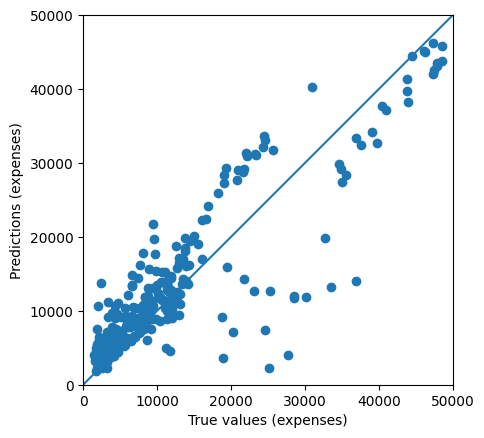

In [20]:
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_features, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 4000:
    print("You passed the challenge. Great job!")
else:
    print("The Mean Abs Error must be less than 4000. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_features).flatten()

a = plt.axes(aspect="equal")
plt.scatter(test_labels, test_predictions)
plt.xlabel("True values (expenses)")
plt.ylabel("Predictions (expenses)")
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

In [21]:
sample = pd.DataFrame(
    [
        {
            "age": 35,  # any integer 18–64
            "sex": "male",  # 'male' or 'female'
            "bmi": 28.5,  # any float (typical: 15–53)
            "children": 2,  # 0, 1, 2, 3, ...
            "smoker": "no",  # 'yes' or 'no'
            "region": "southeast",  # 'northeast', 'northwest', 'southeast', or 'southwest'
        }
    ]
)

# Apply the same encoding as the training data
sample["sex"] = sample["sex"].map({"male": 0, "female": 1})
sample["smoker"] = sample["smoker"].map({"no": 0, "yes": 1})
sample = pd.get_dummies(sample, columns=["region"], dtype=float)

# Match the training feature column order (fill missing one-hot columns with 0)
feature_columns = [c for c in dataset.columns if c != "expenses"]
sample = sample.reindex(columns=feature_columns, fill_value=0.0)

# Predict
sample_array = np.array(sample, dtype="float32")
predicted_cost = model.predict(sample_array, verbose=0)[0][0]
print(f"Predicted annual healthcare cost: ${predicted_cost:,.2f}")

Predicted annual healthcare cost: $5,061.81
